## **TESTING MODEL DIAGNOSTICS FOR MULTIPLE LINEAR REGRESSION**

In [17]:
### Load the Library for Data Importation and Model Estimation
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Load Libraries for Diagnostic Tests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import jarque_bera, durbin_watson

### **Import Data**

In [9]:
df = pd.read_csv("training model.csv")
df.head()                 

,year,CPI,ExchRate,LendIntRates
0,1987,7.872727,16.45499,14.0000
1,1988,8.848083,17.74710,15.0000
2,1989,10.035029,20.57247,17.2500
3,1990,11.602322,22.91477,18.7500
4,1991,13.805882,27.50870,18.9975


### **Create the X and y Variables**

In [11]:
y = df["CPI"]
X = df[["ExchRate", "LendIntRates"]]

In [12]:
X.head()

,ExchRate,LendIntRates
0,16.45499,14.0000
1,17.74710,15.0000
2,20.57247,17.2500
3,22.91477,18.7500
4,27.50870,18.9975


In [13]:
y.head()

0     7.872727
1     8.848083
2    10.035029
3    11.602322
4    13.805882
Name: CPI, dtype: float64

### **Add Constant to the X-Matrix of Predictors**

In [14]:
X = sm.add_constant(X)
X.head()

,const,ExchRate,LendIntRates
0,1.0,16.45499,14.0000
1,1.0,17.74710,15.0000
2,1.0,20.57247,17.2500
3,1.0,22.91477,18.7500
4,1.0,27.50870,18.9975


### **Fit the Linear Model**

In [16]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CPI   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     38.96
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           4.11e-08
Time:                        19:19:53   Log-Likelihood:                -110.21
No. Observations:                  26   AIC:                             226.4
Df Residuals:                      23   BIC:                             230.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.8998     15.023      0.526   

### **MODELS DIAGNOTICS TESTS**

#### **1. Normality of the Residuals**

##### **(a) Histogram**

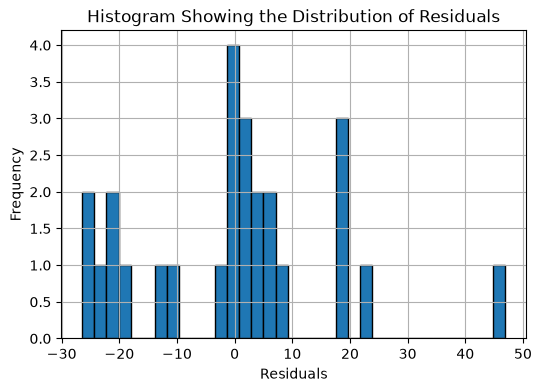

In [22]:
plt.figure(figsize = (6, 4))
plt.hist(model.resid, bins = 35, edgecolor = "black")

plt.title("Histogram Showing the Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

##### **(b) Q-Q Plot**

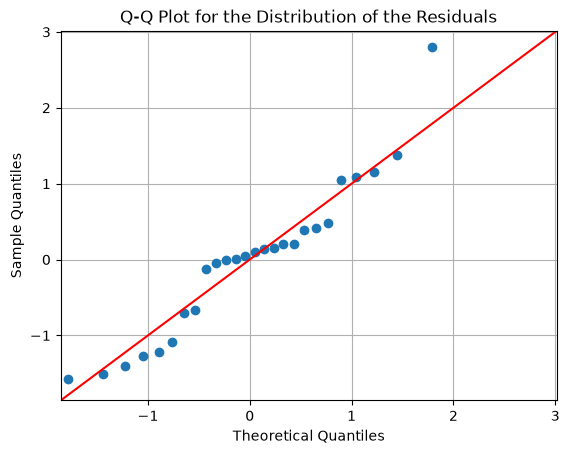

In [24]:
sm.qqplot(model.resid, line = '45', fit =True)
plt.title("Q-Q Plot for the Distribution of the Residuals")
plt.grid(True)
plt.show()

##### **(c) Inferential Test (Shapiro-Wilks Test) for Normality**

> Null hypothesis: Residuals follow a normal distribution

> Alternative hypothesis: Residuals do NOT follow a normal distribution

###### **Decision Criteria** 
> Reject the null hypothesis if and and only the p-value is less than 0.05

In [26]:
from scipy.stats import shapiro
stat, p = shapiro(model.resid)

print("Shapiro -Wilks Statistics:", stat)
print("P-value:", p)

if p> 0.05:
    print("The residuals are normally distributed")
else:
    print("The residuals are NOT normally distributed")


Shapiro -Wilks Statistics: 0.9386479628813943
P-value: 0.12467871064108926
The residuals are normally distributed


#### **2. Multicollinearity**

In [27]:
vif = pd.DataFrame({
    "Variable":X.columns,
    "VIF":[variance_inflation_factor(X.values, i)
          for i in range(X.shape[1])]
})
print(vif)

       Variable        VIF
0         const  18.440192
1      ExchRate   1.009553
2  LendIntRates   1.009553


#### **3. Heteroscedasticity**

> Null hypothesis: The variance of the residuals is constant over time

> Alternative hypothesis: The variance of the residuals varies over time (The variance is non-constant)

In [29]:
bp_test = het_breuschpagan(model.resid, model.model.exog)

labels = [
    "LM Statistics",
    "LM-Test p-value",
    "F-Statistics",
    "FTest p-value"
]
print(pd.Series(bp_test, index = labels))

LM Statistics      8.237265
LM-Test p-value    0.016267
F-Statistics       5.332994
FTest p-value      0.012507
dtype: float64


#### **4. Autocorrelation - Independence of the Residuals**

The test is conducted using Durbin Watson Test statistic

> Autocorrelation test value ranges between 0 and 4

> 1.5. < DW-test < 2.5: No autocorrelation

> DW-test < 1.5 : Positive autocorrelation

> DW-test > 2.5 : Negative Autocorrelation

In [36]:
model.predict()

array([ 7.93349537,  8.08375777,  8.31815895,  9.05534693, 14.50527553,
       17.39148437, 36.78671034, 25.02719065, 30.23730037, 30.02079419,
       37.33164586, 40.52399806, 63.70255789, 71.17078091, 78.16724085,
       80.20456046, 79.43526101, 89.54238339, 84.43697224, 78.94502018,
       73.32597401, 74.67306259, 83.85755878, 86.88334718, 98.00891739,
       85.63749031])

In [34]:
model.resid

0     -0.060768
1      0.764325
2      1.716870
3      2.546975
4     -0.699394
5      0.187872
6    -11.124563
7      8.029347
8      3.333045
9      6.525256
10     3.352027
11     2.363077
12   -18.337003
13   -21.280121
14   -25.417024
15   -26.417458
16   -20.374211
17   -23.515133
18   -11.864945
19    -1.995105
20     6.910115
21    17.689803
22    18.237937
23    19.381569
24    23.156437
25    46.891069
dtype: float64

In [32]:
y['Residuals'] = model.resid

In [33]:
y.head()

0     7.872727
1     8.848083
2    10.035029
3    11.602322
4    13.805882
Name: CPI, dtype: object

### **Put together the Observed y, Predicted and Residuals**

In [44]:
df2 = pd.DataFrame({
    "Oberved": y,
    "Predicted": model.fittedvalues,
    "Residuals": model.resid
})
df2.head(20)

,Oberved,Predicted,Residuals
0,7.872727,7.933495,-0.060768
1,8.848083,8.083758,0.764325
2,10.035029,8.318159,1.716870
3,11.602322,9.055347,2.546975
4,13.805882,14.505276,-0.699394
5,17.579356,17.391484,0.187872
6,25.662147,36.786710,-11.124563
7,33.056538,25.027191,8.029347
8,33.570345,30.237300,3.333045
9,36.54605,30.020794,6.525256


In [47]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(model.resid)

print("Durbin Watson Statistics:", dw)

Durbin Watson Statistics: 0.28162582227632466


### **Note!!**
The residuals are positively autocorrelated. The independence of the resiuals assumption is violated.